In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("./gender_classification_v7.csv")

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print("duplicates: ", df.duplicated().sum())


   long_hair  forehead_width_cm  forehead_height_cm  nose_wide  nose_long  \
0          1               11.8                 6.1          1          0   
1          0               14.0                 5.4          0          0   
2          0               11.8                 6.3          1          1   
3          0               14.4                 6.1          0          1   
4          1               13.5                 5.9          0          0   

   lips_thin  distance_nose_to_lip_long  gender  
0          1                          1    Male  
1          1                          0  Female  
2          1                          1    Male  
3          1                          1    Male  
4          0                          0  Female  
<class 'pandas.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                

In [ ]:
df=df.drop_duplicates()
print (df["gender"].value_counts(normalize=True))

                           long_hair  forehead_width_cm  forehead_height_cm  \
long_hair                   1.000000          -0.013151           -0.005145   
forehead_width_cm          -0.013151           1.000000            0.079665   
forehead_height_cm         -0.005145           0.079665            1.000000   
nose_wide                   0.024123           0.212223            0.180526   
nose_long                   0.042556           0.212032            0.153438   
lips_thin                   0.037514           0.220566            0.170018   
distance_nose_to_lip_long  -0.011362           0.206636            0.183036   

                           nose_wide  nose_long  lips_thin  \
long_hair                   0.024123   0.042556   0.037514   
forehead_width_cm           0.212223   0.212032   0.220566   
forehead_height_cm          0.180526   0.153438   0.170018   
nose_wide                   1.000000   0.394605   0.379767   
nose_long                   0.394605   1.000000   0.38486

C:\Users\DELL\AppData\Local\Temp\ipykernel_14612\3751434993.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='gender', palette=['#4C72B0', '#DD8452'])


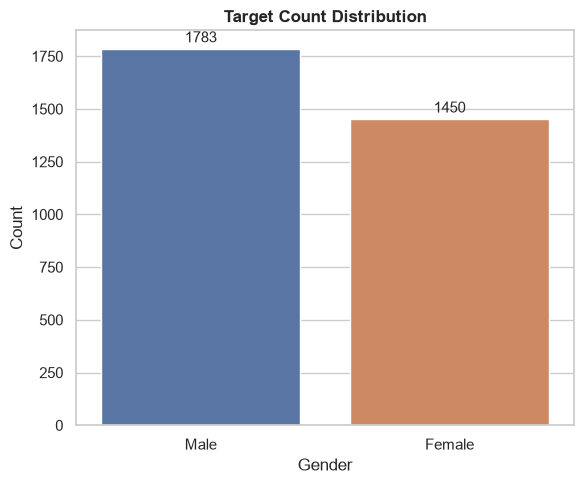

In [5]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))

ax = sns.countplot(data=df, x='gender', palette=['#4C72B0', '#DD8452'])
plt.title('Target Count Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_14612\3871907042.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='forehead_width_cm',
C:\Users\DELL\AppData\Local\Temp\ipykernel_14612\3871907042.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='forehead_height_cm',


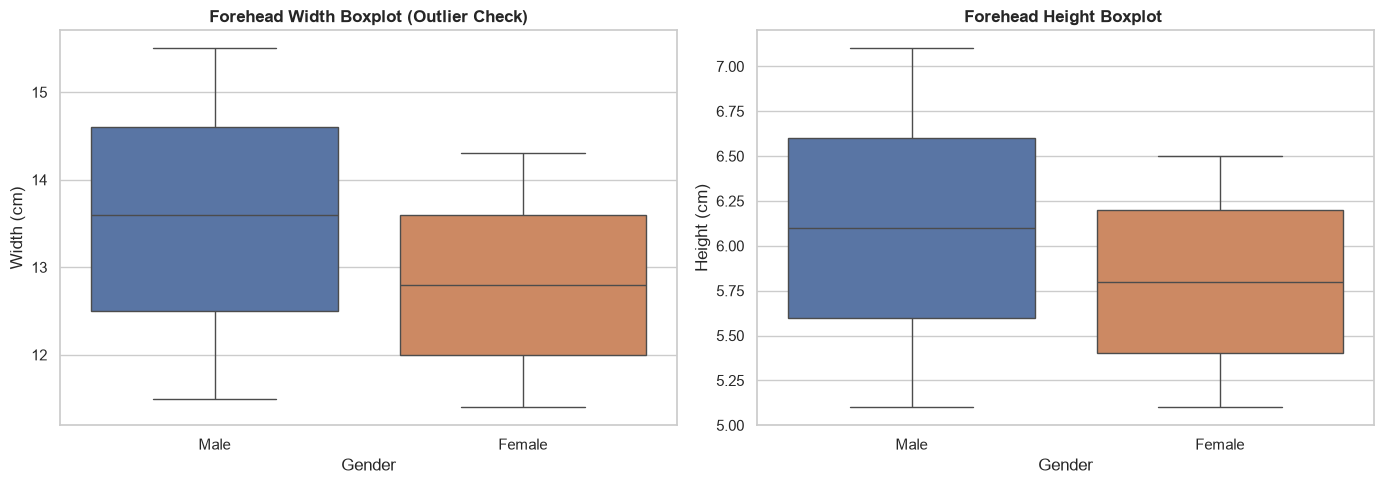

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='gender', y='forehead_width_cm', 
            palette=['#4C72B0', '#DD8452'], ax=axes[0])
axes[0].set_title('Forehead Width Boxplot (Outlier Check)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Width (cm)')

sns.boxplot(data=df, x='gender', y='forehead_height_cm', 
            palette=['#4C72B0', '#DD8452'], ax=axes[1])
axes[1].set_title('Forehead Height Boxplot ', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Height (cm)')

plt.tight_layout()
plt.show()

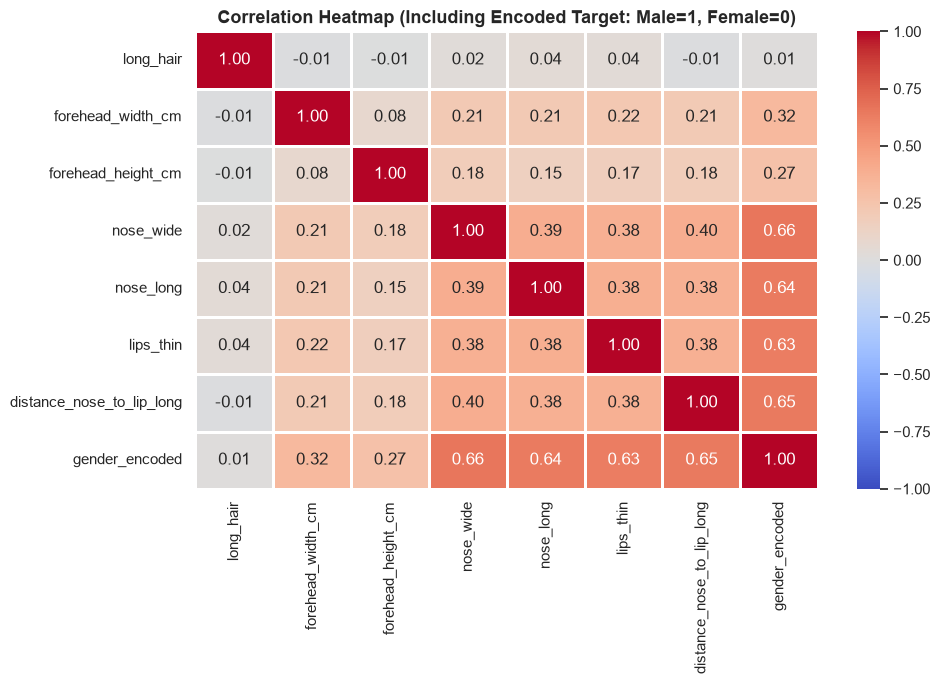

In [7]:
df_corr = df.copy()
df_corr['gender_encoded'] = (df_corr['gender'] == 'Male').astype(int)

plt.figure(figsize=(10, 7))
corr_matrix = df_corr.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.8, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Including Encoded Target: Male=1, Female=0)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = df.drop(columns=['gender'])
y = df['gender']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  
 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

C_values = [0.01, 0.1, 1, 10, 100]

results = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000)
    
    model.fit(x_train_scaled, y_train)
    
    # Train predictions
    y_train_pred = model.predict(x_train_scaled)
    
    # Test predictions
    y_test_pred = model.predict(x_test_scaled)
    
    # Test probabilities
    y_test_proba = model.predict_proba(x_test_scaled)[:, 1]
    
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_log_loss = log_loss(y_test, y_test_proba)
    
    results.append([
        C,
        train_accuracy,
        test_accuracy,
        test_log_loss
    ])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "C",
        "Train Accuracy",
        "Test Accuracy",
        "Test Log Loss"
    ]
)

results_df

,C,Train Accuracy,Test Accuracy,Test Log Loss
0,0.01,0.948569,0.953632,0.150763
1,0.10,0.950889,0.959815,0.106640
2,1.00,0.950889,0.959815,0.102143
3,10.00,0.950889,0.959815,0.101924
4,100.00,0.950889,0.959815,0.101913


Regularization Analysis:
Different values of C were tested to study the effect of regularization on Logistic Regression. A smaller C applies stronger regularization. The results show that C=0.01 slightly reduces the model's ability to fit the data, while values from 0.1 to 100 produce very similar accuracy. The model does not show a significant gap between training and test accuracy, indicating no clear evidence of overfitting. The Log Loss also becomes stable around C ≥ 1.

In [15]:
final_model = LogisticRegression(C=1, max_iter=1000)

final_model.fit(x_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [16]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss
)

y_pred = final_model.predict(x_test_scaled)
y_proba = final_model.predict_proba(x_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Log Loss:", log_loss(y_test, y_proba))

Accuracy: 0.9598145285935085

Classification Report:
              precision    recall  f1-score   support

      Female       0.95      0.96      0.96       308
        Male       0.96      0.96      0.96       339

    accuracy                           0.96       647
   macro avg       0.96      0.96      0.96       647
weighted avg       0.96      0.96      0.96       647

Log Loss: 0.1021429797469812
